# KNN (K Nearest Neighbours)

In [2]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [3]:
wine.data, wine.feature_names

(array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 ['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'])

In [4]:
wine.target, wine.target_names

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2]),
 array(['class_0', 'class_1', 'class_2'], dtype='<U7'))

In [5]:
wine.target.shape, wine.data.shape

((178,), (178, 13))

In [6]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["wine_class"] = wine.target

# om det är olika längd på det du vill lägga till i dataframen så använder man concat för att då få nullvärden på de som saknas
# df_wine_classes = pd.DataFrame(wine.target, columns=["wine_class"])
# df = pd.concat([df, df_wine_classes], axis=1)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


## EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_

In [8]:
df.shape, df.columns

((178, 14),
 Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
        'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
        'proanthocyanins', 'color_intensity', 'hue',
        'od280/od315_of_diluted_wines', 'proline', 'wine_class'],
       dtype='object'))

In [9]:
df.describe().T.drop("count", axis=1)

,mean,std,min,25%,50%,75%,max
alcohol,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
wine_class                      0
dtype: int64

### feature selection/feature engineering with correlation heatmap

<Axes: >

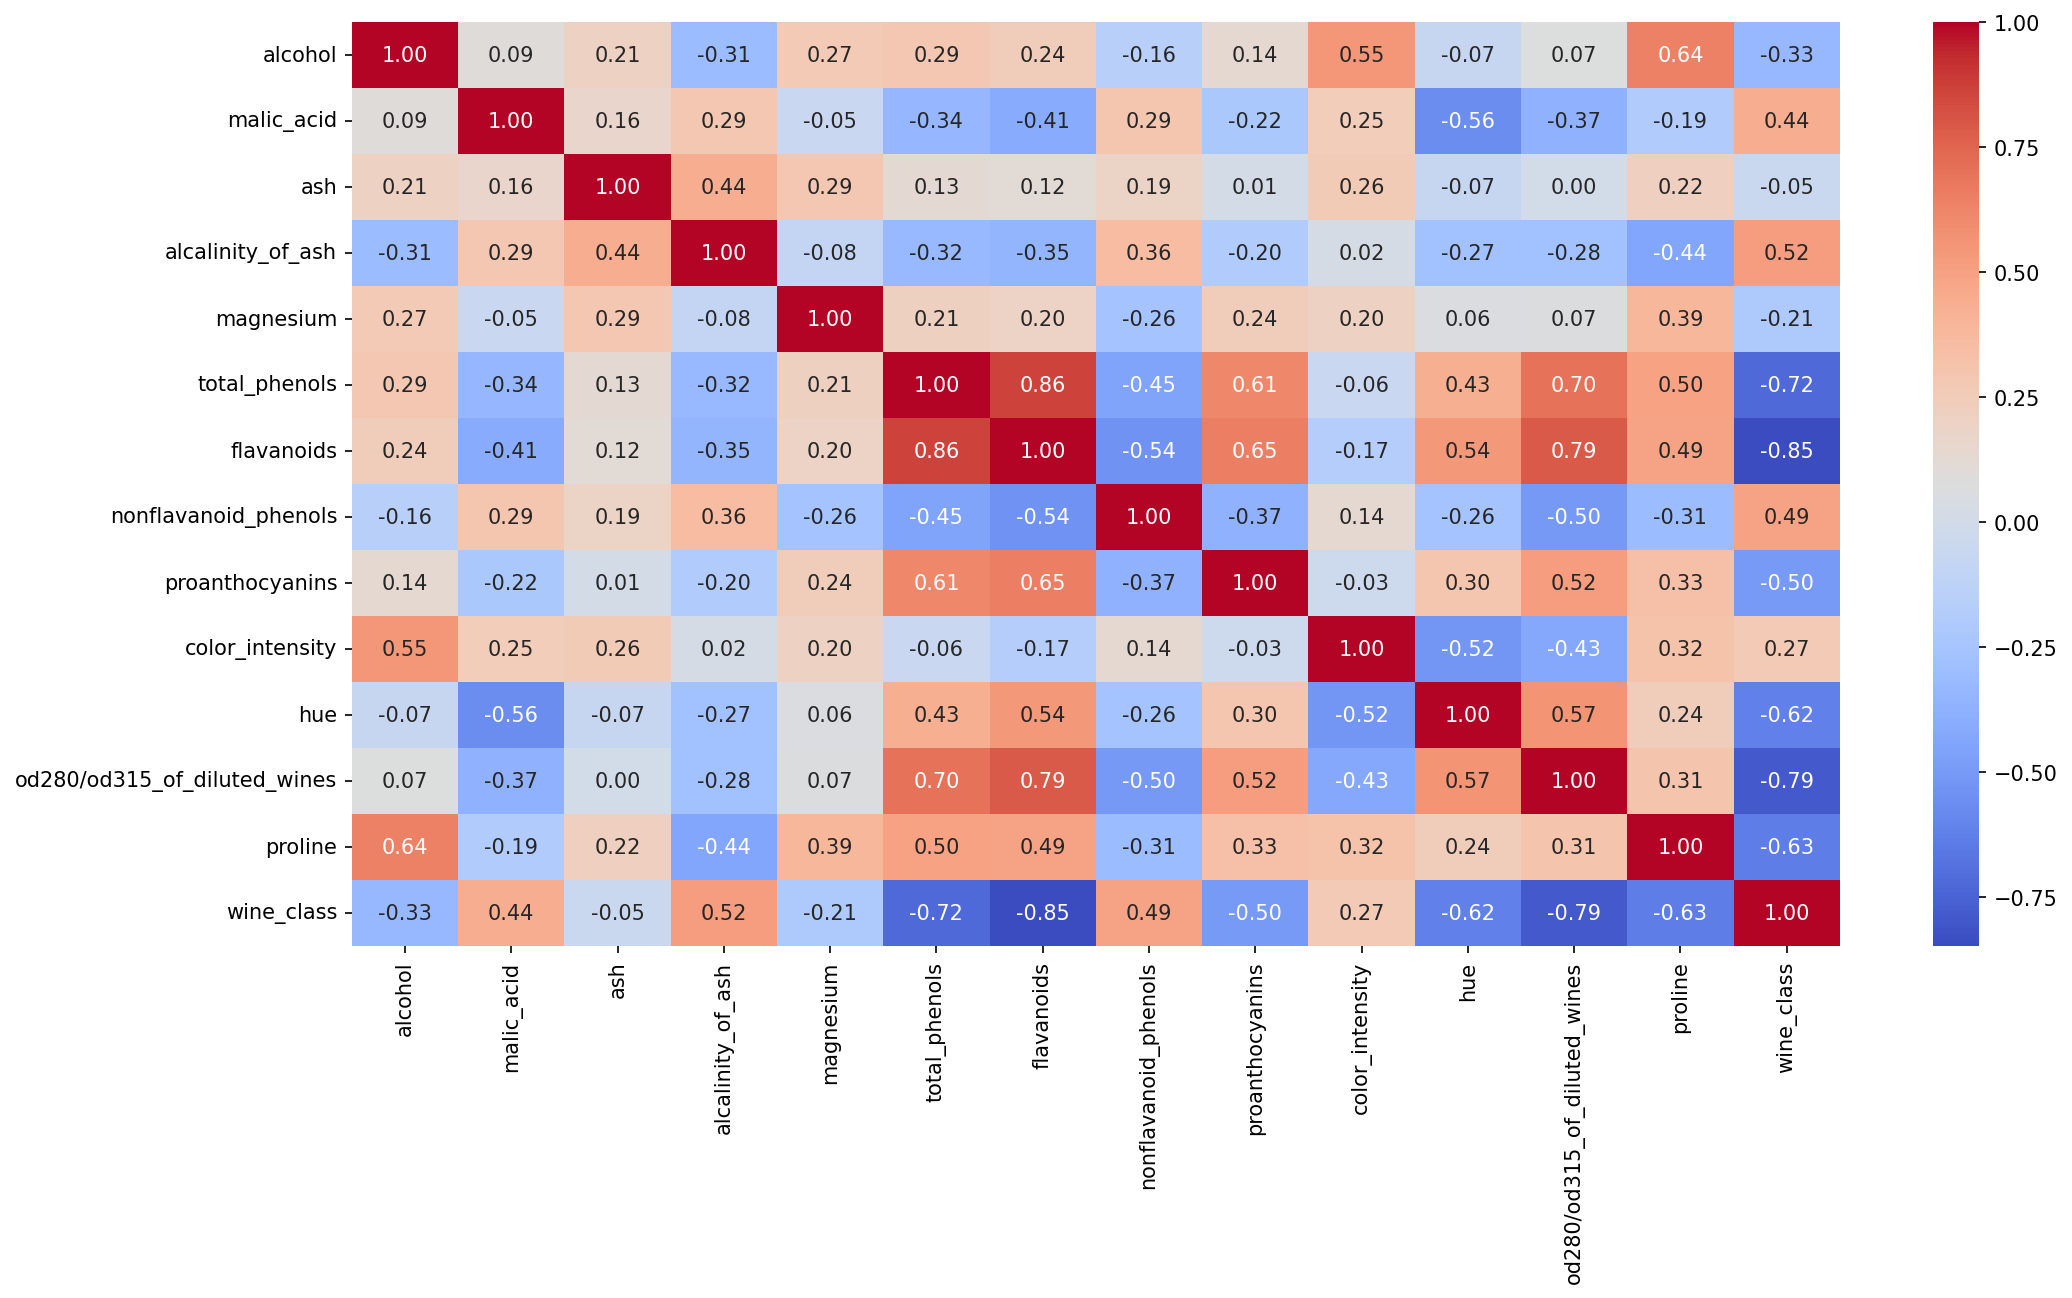

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(16,8), dpi=150)

# hög positiv correlation betyder att dom ökar tillsammans
# hög negativ corr betyder att dom minskar tillsammans
# 0.8/-0.8 eller högre/lägre kan man börja ta bort
# vi behöver bara en av dom som har hög correlation, tex flavanoids vs total_phenols har 0.86, behöver bara en av dessa
# ta bort en av dessa , ta bort den som har lägs corr mot target
# total_phenols har lägre corr mot target än flavanoids, ta bort total_phenols
# ash har -0.05 mot target, påverkar inte mycket, kan kastas
# magnesium har -0.21 mot target, kan möjligtvis kastas
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

In [12]:
df.drop(["ash", "total_phenols", "magnesium"], axis=1, inplace=True)

In [13]:
# sns.pairplot(df, hue="wine_class", diag_kind="kde")

## KNN

In [14]:
X, y = df.drop("wine_class", axis=1), df["wine_class"]

X.shape, y.shape

((178, 10), (178,))

## train|test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [16]:
X_train.shape, X_test.shape

((89, 10), (89, 10))

## scaling
### väldigt viktigt att skala datan i KNN

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }")
print(f"{scaled_X_train.min() = }")
print(f"{scaled_X_train.max() = }\n")
print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }")
print(f"{scaled_X_test.min() = }")
print(f"{scaled_X_test.max() = }")

scaled_X_train.mean() = np.float64(0.4095417973786147)
scaled_X_train.std() = np.float64(0.2417970356362837)
scaled_X_train.min() = np.float64(0.0)
scaled_X_train.max() = np.float64(1.0)

scaled_X_test.mean() = np.float64(0.41064810689428005)
scaled_X_test.std() = np.float64(0.23356721849130777)
scaled_X_test.min() = np.float64(-0.05077262693156731)
scaled_X_test.max() = np.float64(1.2428256070640176)


### train KNN model

In [18]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)

y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 1, 0, 2,
       1])

In [19]:
y_test.values

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 2,
       1])

In [20]:
y_pred - y_test.values

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        1,  0,  0,  0])

## evaluate model

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.97      0.94      0.96        34
           2       0.96      1.00      0.98        22

    accuracy                           0.97        89
   macro avg       0.97      0.97      0.97        89
weighted avg       0.97      0.97      0.97        89



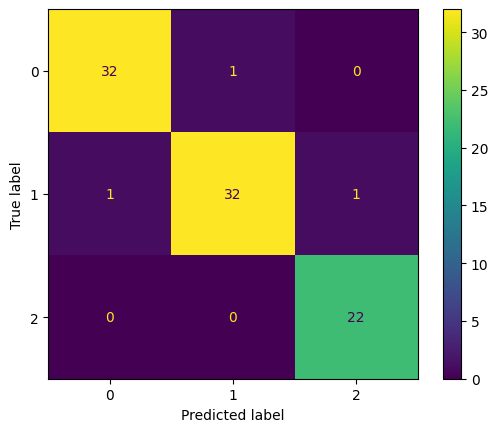

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

## tune hyperparameter k (n_neighbours) with elbow plot

In [22]:
df["wine_class"].value_counts()

wine_class
1    71
0    59
2    48
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import accuracy_score

# balanserat dataset, kör på accuracy
error = 1-accuracy_score(y_test, y_pred)
error

0.0337078651685393

## TODO: plot graph of errors in y and k in x

In [31]:
error_list = []
for k in range(1,50):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    error = 1-accuracy_score(y_test,y_pred)
    error_list.append(error)

error_list

[0.0337078651685393,
 0.0674157303370787,
 0.0337078651685393,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0337078651685393,
 0.0449438202247191,
 0.0337078651685393,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.0337078651685393,
 0.022471910112359605,
 0.0337078651685393,
 0.022471910112359605,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.033707865168539

## elbow plot

[Text(0.5, 0, 'k neighbors'),
 Text(0, 0.5, 'error'),
 Text(0.5, 1.0, 'Elbow plot to choose k')]

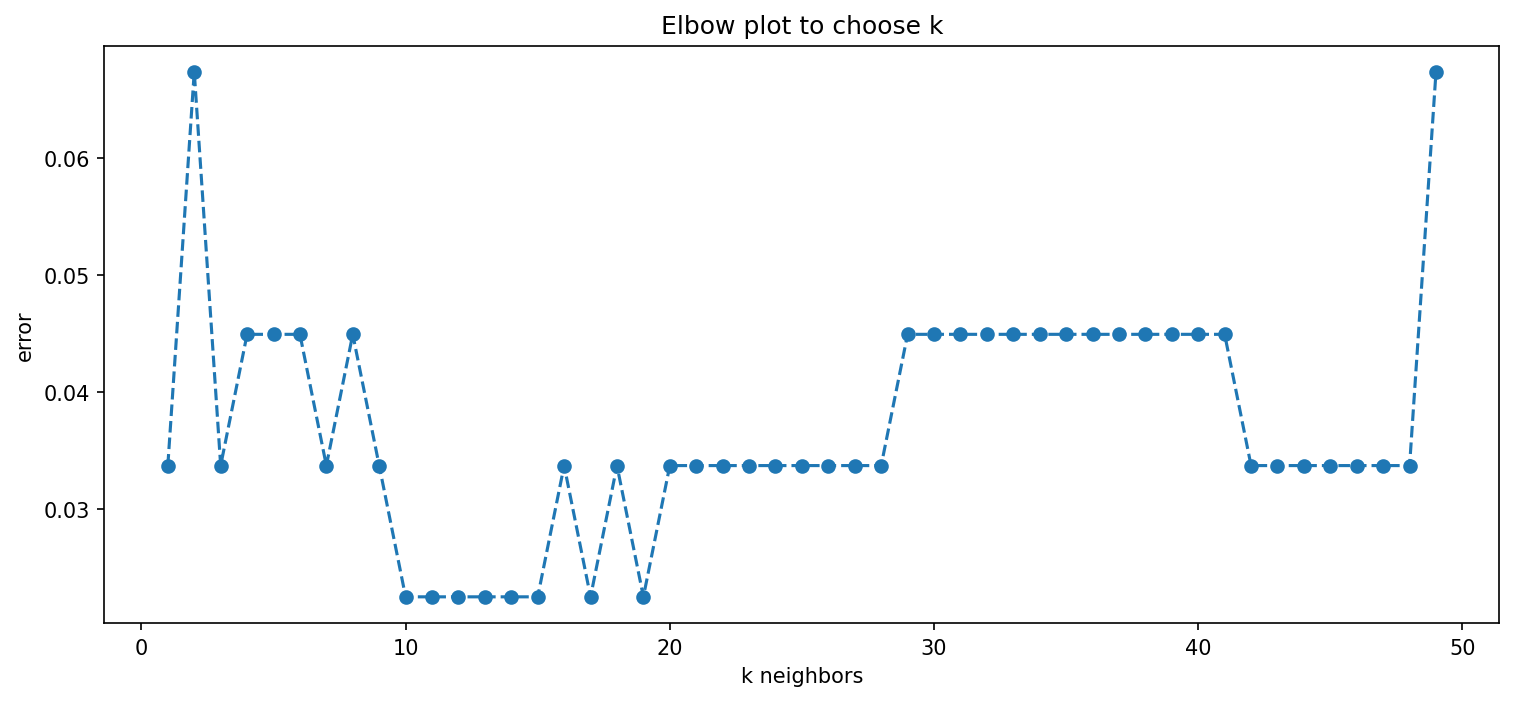

In [37]:
fig, ax = plt.subplots(1, figsize=(12,5), dpi=150)
plt.plot(range(1,50), error_list, '--o')
ax.set(xlabel="k neighbors", ylabel="error", title="Elbow plot to choose k")

Choose k=10 or 11, and train on all data(train and test data), save/export model

To be more robust and avoid data leakage
- do train|val|test split (use train_test_split twice)
- calculate error based on validation data
- choose k on elbow plot with validation data
- train on train + validation data
- evaluate on test data
- train on all data
- export model